<a href="https://colab.research.google.com/github/tamaki-gth/cartpole_project/blob/main/2link_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import numpy as np

m1=1.96
m2=1.68
#m2=8.78
l1=0.32
l2=0.44
lf=0.25
lh=0.19
mf=1.12
mh=0.42
mo=0.14
#mo=7.24
g=9.8
J1=0.017
J2=0.15
trq1=2
trq2=2
p1=0.16
p2=0.21
C1=0.05
C2=0.01
tau=0.01

def f(z,m1,m2,l1,l2,p1,p2,J1,J2,action,g):

    theta1,theta1_dot,theta2,theta2_dot=z
    trq1,trq2=action

    A1=np.array([[m1*p1**2+m2*(l1**2+p2**2+2*l1*p2*np.cos(theta2))+J1+J2,m2*(p2**2+l1*p2*np.cos(theta2))+J2],[m2*(p2**2+l1*p2*np.cos(theta2))+J2,m2*p2**2+J2]])
    A2=np.array([[-m2*l1*p2*np.sin(theta2)*(2*theta1_dot*theta2_dot+theta2_dot**2)],[m2*l1*p2*np.sin(theta2)*theta1_dot**2]])
    A3=np.array([[m1*g*p1*np.cos(theta1)+m2*g*(l1*np.cos(theta1)+p2*np.cos(theta1+theta2))],[m2*g*p2*np.cos(theta1+theta2)]])
    C=np.array([[C1*theta1_dot],[C2*theta2_dot]])
    trq=np.array([[trq1],[trq2]])
    A1_inv=np.linalg.inv(A1)

    h=A1_inv@trq-A1_inv@A2-A1_inv@A3-A1_inv@C

    return np.array([theta1_dot, h[0,0], theta2_dot, h[1,0]])

def RungeKutta(z,tau,m1,m2,l1,l2,p1,p2,J1,J2,action,g):
    k1=f(z,m1,m2,l1,l2,p1,p2,J1,J2,action,g)
    k2=f(z+k1*tau/2,m1,m2,l1,l2,p1,p2,J1,J2,action,g)
    k3=f(z+k2*tau/2,m1,m2,l1,l2,p1,p2,J1,J2,action,g)
    k4=f(z+k3*tau,m1,m2,l1,l2,p1,p2,J1,J2,action,g)
    return z+tau/6*(k1+2*k2+2*k3+k4)


In [11]:
def forward_kinematics_and_velocity(z):
    theta1, theta1_dot, theta2, theta2_dot = z

    # 手先位置
    x = l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    y = l1 * np.sin(theta1) + l2 * np.sin(theta1 + theta2)

    # ヤコビアン
    dx_dtheta1 = -l1 * np.sin(theta1) - l2 * np.sin(theta1 + theta2)
    dx_dtheta2 = -l2 * np.sin(theta1 + theta2)
    dy_dtheta1 =  l1 * np.cos(theta1) + l2 * np.cos(theta1 + theta2)
    dy_dtheta2 =  l2 * np.cos(theta1 + theta2)

    x_dot = dx_dtheta1 * theta1_dot + dx_dtheta2 * theta2_dot
    y_dot = dy_dtheta1 * theta1_dot + dy_dtheta2 * theta2_dot

    v = np.sqrt(x_dot**2 + y_dot**2)
    return x, y, x_dot, y_dot, v

In [12]:
DT=0.01
class TwolinkEnv:

    def __init__(self):
        self.scale=0.01
        self.trq_limit_1 = 16
        self.trq_limit_2 = 10
        self.reset()

    def reset(self):
        self.z = np.array([0.0, 0.0, 0.0, 0.0])
        self.max_R = 0.0  # エピソード内の最高飛距離を記憶
        self.steps = 0
        return self.z

    def step(self, action):
        self.steps+=1
        tau1, tau2 = action

        tau1 = np.clip(tau1, -self.trq_limit_1, self.trq_limit_1)
        tau2 = np.clip(tau2, -self.trq_limit_2, self.trq_limit_2)

        self.z = RungeKutta(self.z, DT,m1, m2, l1, l2, p1, p2, J1, J2,(tau1, tau2),g)

        theta1, theta1_dot, theta2, theta2_dot = self.z

        _, _, x_dot, y_dot, v = forward_kinematics_and_velocity(self.z)

        if y_dot>0:
          theta=np.arctan2(y_dot,x_dot)
          R = (v**2/g)*abs(np.sin(2*theta))
        else:
          R=0.0

        #最高飛距離を更新
        if R>self.max_R:
          self.max_R=R


        ce1 = abs(tau1 * theta1_dot) * DT
        ce2 = abs(tau2 * theta2_dot) * DT
        ce_step = ce1 + ce2

        reward=-self.scale*ce_step
        done = False
        if self.steps >= 500:  # 2秒で打ち切り
            done = True
            reward += self.max_R * 10.0  # 飛距離のボーナスを最後に大きく与える

        return self.z, reward, done, {}



In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal

class ActorCritic(nn.Module):
    def __init__(self):
        super().__init__()

        self.actor = nn.Sequential(
            nn.Linear(4, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )

        self.mu = nn.Linear(64, 2)
        self.log_std = nn.Parameter(torch.zeros(2))

        self.critic = nn.Sequential(
            nn.Linear(4, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, state):
        x = self.actor(state)
        mu = self.mu(x)
        std = torch.exp(self.log_std)
        dist = Normal(mu, std)
        value = self.critic(state)
        return dist, value

In [14]:
class PPO:
    def __init__(self):
        self.model = ActorCritic()
        self.optimizer = optim.Adam(self.model.parameters(), lr=3e-4)

        self.gamma = 0.99
        self.eps_clip = 0.2
        self.batch_size = 64  # ミニバッチサイズを追加

    def select_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0)  # ★4次元そのまま

        dist, value = self.model(state)

        action = dist.sample()

        log_prob = dist.log_prob(action).sum(dim=-1)  # ★2次元合計

        return action.detach().squeeze(0).numpy(), log_prob.detach(), value.detach()

    def update(self, memory):
        states = torch.FloatTensor(np.array(memory['states']))
        actions = torch.FloatTensor(np.array(memory['actions']))
        old_log_probs = torch.FloatTensor(np.array(memory['log_probs']))
        returns = torch.FloatTensor(np.array(memory['returns']))
        dataset_size = states.size(0)

        # 10エポック回す
        for _ in range(10):
            # データをシャッフルするためのインデックス
            permutation = torch.randperm(dataset_size)

            for start_idx in range(0, dataset_size, self.batch_size):
                batch_indices = permutation[start_idx : start_idx + self.batch_size]

                b_states = states[batch_indices]
                b_actions = actions[batch_indices]
                b_old_log_probs = old_log_probs[batch_indices]
                b_returns = returns[batch_indices]

                dist, values = self.model(b_states)
                values = values.squeeze(-1) # (batch_size,) に揃える

                log_probs = dist.log_prob(b_actions).sum(dim=-1)
                ratio = torch.exp(log_probs - b_old_log_probs)

                advantages = b_returns - values.detach()

                surr1 = ratio * advantages
                surr2 = torch.clamp(ratio, 1 - self.eps_clip, 1 + self.eps_clip) * advantages

                actor_loss = -torch.min(surr1, surr2).mean()
                critic_loss = (b_returns - values).pow(2).mean()

                loss = actor_loss + 0.5 * critic_loss

                self.optimizer.zero_grad()
                loss.backward()
                # 勾配爆発を防ぐクリッピングを追加
                nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=0.5)
                self.optimizer.step()

In [15]:
from IPython.display import HTML
import matplotlib.pyplot as plt
from matplotlib import animation
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
from matplotlib import animation
import numpy as np

def save_animation(z_array, l1, l2,filename="2link.mp4"):

    theta1 = z_array[:, 0]
    theta2 = z_array[:, 2]

    # joint 1
    x1 = l1 * np.cos(theta1)
    y1 = l1 * np.sin(theta1)

    # joint 2（先端）
    x2 = x1 + l2 * np.cos(theta1 + theta2)
    y2 = y1 + l2 * np.sin(theta1 + theta2)

    fig, ax = plt.subplots()

    def update(i):
        ax.clear()
        ax.set_xlim(- (l1 + l2), (l1 + l2))
        ax.set_ylim(- (l1 + l2), (l1 + l2))
        ax.set_aspect('equal')

        # link1
        ax.plot([0, x1[i]], [0, y1[i]], "bo-")

        # link2
        ax.plot([x1[i], x2[i]], [y1[i], y2[i]], "ro-")

    ani = animation.FuncAnimation(fig, update, frames=len(z_array))

    filename = "/content/drive/MyDrive/lab_activity/2link/2link.mp4"
    writer = animation.FFMpegWriter(fps=100)

    ani.save(filename, writer=writer)

    print("len(z_array):", len(z_array))

    plt.close()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


ストリーミング出力は最後の 5000 行に切り捨てられました。
Episode 5002 | Reward 20.17 | Step 499
Episode 5003 | Reward 43.74 | Step 499
Episode 5004 | Reward 11.16 | Step 499
Episode 5005 | Reward 102.26 | Step 499
Episode 5006 | Reward 17.26 | Step 499
Episode 5007 | Reward 54.07 | Step 499
Episode 5008 | Reward 33.95 | Step 499
Episode 5009 | Reward 55.64 | Step 499
Episode 5010 | Reward 86.30 | Step 499
Episode 5011 | Reward 30.31 | Step 499
Episode 5012 | Reward 96.17 | Step 499
Episode 5013 | Reward 43.92 | Step 499
Episode 5014 | Reward 12.07 | Step 499
Episode 5015 | Reward 13.70 | Step 499
Episode 5016 | Reward 18.75 | Step 499
Episode 5017 | Reward 35.96 | Step 499
Episode 5018 | Reward 18.63 | Step 499
Episode 5019 | Reward 30.79 | Step 499
Episode 5020 | Reward 26.64 | Step 499
Episode 5021 | Reward 27.73 | Step 499
Episode 5022 | Reward 9.02 | Step 499
Episode 5023 | Reward 138.97 | Step 499
Episode 5024 | Reward 41.47 | Step 499
Episode 5025 | Reward 31.05 | Step 499
Episode 5026 | Reward 44.10 | S

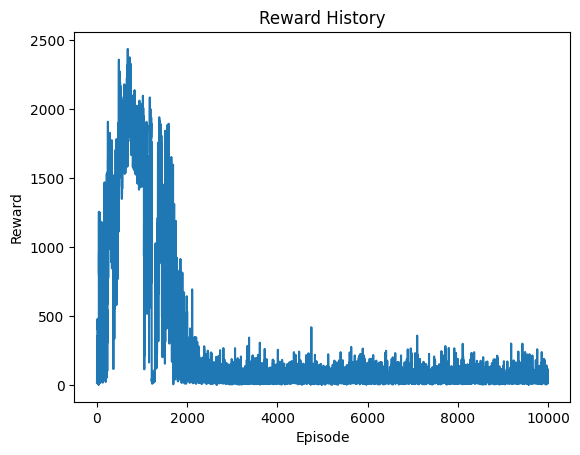

In [16]:
import numpy as np
import os

def train():

    env = TwolinkEnv()
    agent = PPO()
    best_reward = -float("inf")
    best_episode = 0

    rewards_history=[]

    max_episodes = 10000
    max_steps = 500

    max_timesteps = max_episodes * max_steps
    timesteps_so_far = 0

    for episode in range(max_episodes):
        state = env.reset()

        record = (episode == max_episodes - 1)

        if record:
            states_record = []
            actions_record = []

        memory = {'states':[], 'actions':[], 'log_probs':[],
                  'rewards':[], 'dones':[]}

        total_reward = 0

        for t in range(max_steps):
            action, log_prob, _ = agent.select_action(state)

            action_env = action * np.array([1.0,1.0])

            next_state, reward, done, _, = env.step(action_env)

            if record:
                states_record.append(state.copy())
                actions_record.append(action_env.copy())

            memory['states'].append(state)
            memory['actions'].append(action)
            memory['log_probs'].append(log_prob)
            memory['rewards'].append(reward)
            memory['dones'].append(done)

            state = next_state
            total_reward += reward
            timesteps_so_far += 1

            if done:
                break

        returns = []
        G = 0
        for r, d in zip(reversed(memory['rewards']), reversed(memory['dones'])):
            if d:
                G = 0
            G = r + agent.gamma * G
            returns.insert(0, G)

        memory['returns'] = returns

        cur_lrmult = max(1.0 - float(timesteps_so_far) / (max_timesteps/2), 0)
        if cur_lrmult < 1e-5:
            cur_lrmult = 1e-5

        for param_group in agent.optimizer.param_groups:
            param_group['lr'] = 3e-4 * cur_lrmult

        agent.update(memory)

        if total_reward > best_reward:
          best_reward = total_reward
          torch.save(agent.model.state_dict(),"/content/drive/MyDrive/lab_activity/2link/weights/best.pth")
          best_episode = episode

        if episode % 100 == 0:
          torch.save(agent.model.state_dict(),f"/content/drive/MyDrive/lab_activity/2link/weights/ep{episode}.pth")

        #torch.save(agent.model.state_dict(), f"/content/drive/MyDrive/lab_activity/weights/ep{episode}.pth")

        print(f"Episode {episode} | Reward {total_reward:.2f} | Step {t}")

        rewards_history.append(total_reward)

        if record:

            states_record = np.array(memory['states'])
            actions_record = np.array(memory['actions'])
            np.save("/content/drive/MyDrive/lab_activity/2link/states.npy", states_record)
            np.save("/content/drive/MyDrive/lab_activity/2link/actions.npy", actions_record)
            save_animation(states_record, l1, l2)
            print(f"Best episode {best_episode}")

            plt.figure()
            plt.plot(rewards_history)
            plt.xlabel("Episode")
            plt.ylabel("Reward")
            plt.title("Reward History")
            plt.show()






train()

 最強の重み（best.pth）を正常に読み込みました。再現用シミュレーションを開始します...


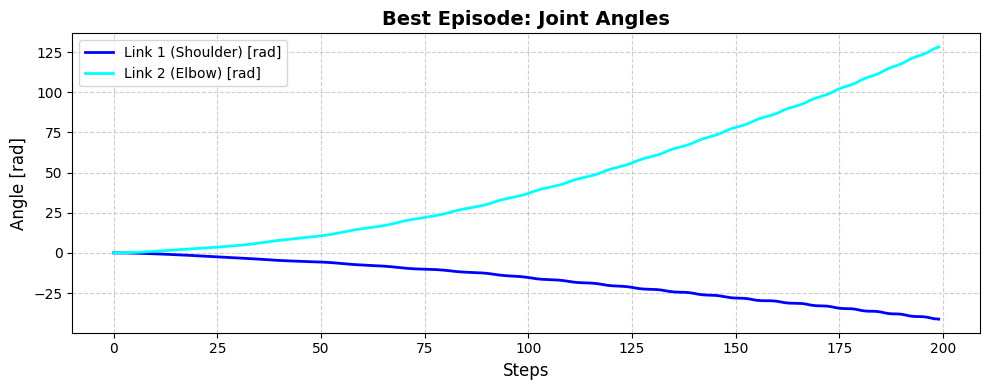

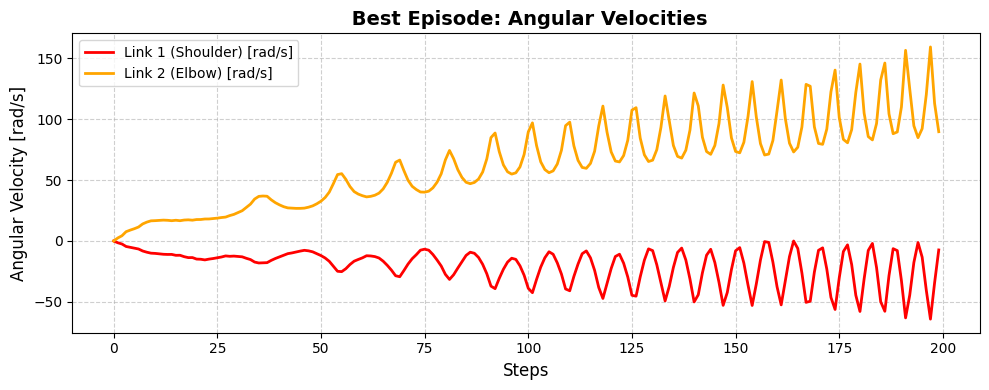

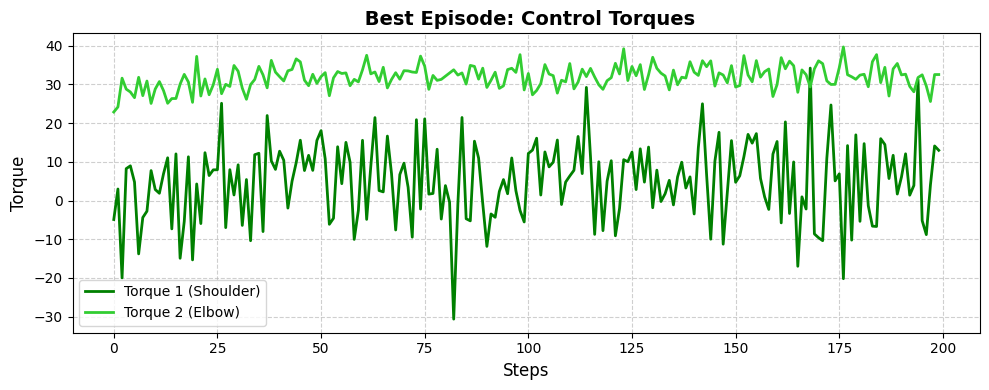

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_best_episode():
    # 1. 環境とエージェントの準備
    env = TwolinkEnv()
    agent = PPO()

    # 2. 保存された「最強の重み」をロードする
    weight_path = "/content/drive/MyDrive/lab_activity/2link/weights/best.pth"
    if not os.path.exists(weight_path):
        print(f" エラー: {weight_path} が見つかりません。一度学習を完了させてください。")
        return

    # 重みを読み込んでネットワークに適用
    agent.model.load_state_dict(torch.load(weight_path))
    agent.model.eval() # 評価モード（ノイズなしの純粋な判断にする）
    print(" 最強の重み（best.pth）を正常に読み込みました。再現用シミュレーションを開始します...")

    # 3. データを記録しながら1エピソード（200ステップ）走らせる
    state = env.reset()
    max_steps = 200

    # 記録用リスト
    steps = []
    theta1_list, theta2_list = [], []
    omega1_list, omega2_list = [], []
    torque1_list, torque2_list = [], []

    for t in range(max_steps):
        # AIに次の行動を決定させる（決定論的な行動を選択）
        with torch.no_grad():
            action, _, _ = agent.select_action(state)

        # 現在の物理状態をバラして記録
        # stateの中身: [θ1, dθ1, θ2, dθ2]
        theta1, omega1, theta2, omega2 = state

        steps.append(t)
        theta1_list.append(theta1)
        theta2_list.append(theta2)
        omega1_list.append(omega1)
        omega2_list.append(omega2)
        torque1_list.append(action[0]) # 肩のトルク
        torque2_list.append(action[1]) # 肘のトルク

        # 環境を進める
        next_state, reward, done, _ = env.step(action)
        state = next_state

        if done:
            break

    # 4. グラフの描画（3つの独立したグラフ）
    steps = np.array(steps)

    # --- グラフ1: 角度 (Angles) ---
    plt.figure(figsize=(10, 4))
    plt.plot(steps, theta1_list, label="Link 1 (Shoulder) [rad]", color="blue", linewidth=2)
    plt.plot(steps, theta2_list, label="Link 2 (Elbow) [rad]", color="cyan", linewidth=2)
    plt.xlabel("Steps", fontsize=12)
    plt.ylabel("Angle [rad]", fontsize=12)
    plt.title("Best Episode: Joint Angles", fontsize=14, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- グラフ2: 角速度 (Angular Velocities) ---
    plt.figure(figsize=(10, 4))
    plt.plot(steps, omega1_list, label="Link 1 (Shoulder) [rad/s]", color="red", linewidth=2)
    plt.plot(steps, omega2_list, label="Link 2 (Elbow) [rad/s]", color="orange", linewidth=2)
    plt.xlabel("Steps", fontsize=12)
    plt.ylabel("Angular Velocity [rad/s]", fontsize=12)
    plt.title(" Best Episode: Angular Velocities", fontsize=14, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

    # --- グラフ3: トルク (Torques / Actions) ---
    plt.figure(figsize=(10, 4))
    plt.plot(steps, torque1_list, label="Torque 1 (Shoulder)", color="green", linewidth=2)
    plt.plot(steps, torque2_list, label="Torque 2 (Elbow)", color="limegreen", linewidth=2)
    plt.xlabel("Steps", fontsize=12)
    plt.ylabel("Torque", fontsize=12)
    plt.title(" Best Episode: Control Torques", fontsize=14, fontweight="bold")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# グラフ実行
plot_best_episode()

In [18]:
def play_best():
    env = TwolinkEnv()

    model = ActorCritic()
    model.load_state_dict(torch.load("/content/drive/MyDrive/lab_activity/2link/weights0523_2/best.pth"))
    model.eval()

    state = env.reset()
    states_record = []
    actions_record = []

    for _ in range(1000):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        dist, _ = model(state_tensor)

        # ←超重要：ランダムじゃなくする
        action = dist.mean.squeeze(0).detach().numpy()

        action_env = action * np.array([1.0,1.0])

        states_record.append(state.copy())
        actions_record.append(action_env.copy())

        state, _, done, _, = env.step(action_env)


        if done:
            break

    save_animation(np.array(states_record), l1,l2, np.array(actions_record))

play_best()

len(z_array): 500


In [ ]:
def play():
    env = TwolinkEnv()
    any_episode=200

    model = ActorCritic()
    model.load_state_dict(torch.load(f"/content/drive/MyDrive/lab_activity/2link/weights/ep{any_episode}.pth"))
    model.eval()

    state = env.reset()
    states_record = []
    actions_record = []

    for _ in range(1000):
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        dist, _ = model(state_tensor)

        # ←超重要：ランダムじゃなくする
        action = dist.mean.squeeze(0).detach().numpy()

        action_env = action * np.array([1.0,1.0])

        states_record.append(state.copy())
        actions_record.append(action_env.copy())

        state, _, done, _, = env.step(action_env)


        if done:
            break

    save_animation(np.array(states_record), l1,l2, np.array(actions_record))

play()

/tmp/ipykernel_1224/128792324.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F = float(action)


len(z_array)  191


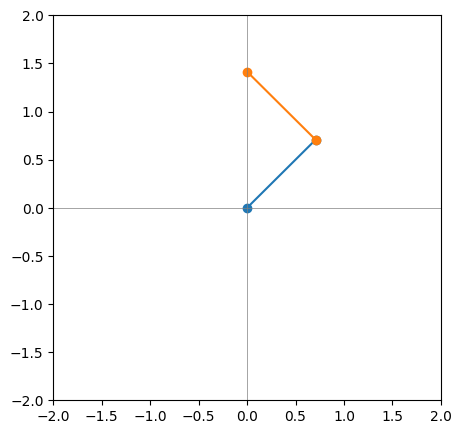

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# リンク長
L1 = 1.0  # 1リンク目の長さ
L2 = 1.0  # 2リンク目の長さ

# 角度（度 → ラジアン）
theta1_deg = 45   # 1リンク目
theta2_deg = 90   # 2リンク目（1リンクからの相対角度とする場合）

theta1 = np.deg2rad(theta1_deg)
theta2 = np.deg2rad(theta2_deg)

# 各関節位置の計算
# 原点 (0, 0) が肩（基準点）
x0, y0 = 0.0, 0.0

# 1リンク目の先端
x1 = L1 * np.cos(theta1)
y1 = L1 * np.sin(theta1)

# 2リンク目の先端（相対角度として足し合わせる）
x2 = x1 + L2 * np.cos(theta1 + theta2)
y2 = y1 + L2 * np.sin(theta1 + theta2)

# 描画
plt.figure(figsize=(5, 5))
plt.plot([x0, x1], [y0, y1], '-o', label='Link 1')
plt.plot([x1, x2], [y1, y2], '-o', label='Link 2')

# 見やすさ調整
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)

plt.xlim(-2, 2)
plt.ylim(-2, 2)


plt.show()

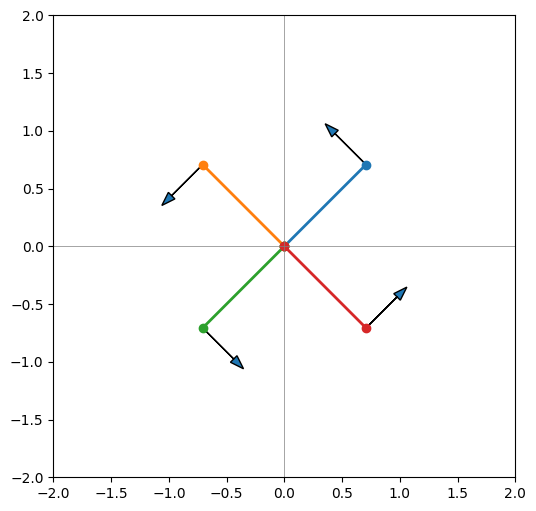

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# リンク長
L1 = 1.0
L2 = 1.0

# 描画したい角度セット（θ1, θ2）
angle_sets = [
    (45, 90),
    (135, 90),
    (225, 90),
    (315, 90)
]

plt.figure(figsize=(6, 6))

for theta1_deg, theta2_deg in angle_sets:
    # ラジアン変換
    theta1 = np.deg2rad(theta1_deg)
    theta2 = np.deg2rad(theta2_deg)

    # 関節位置
    x0, y0 = 0.0, 0.0
    x1 = L1 * np.cos(theta1)
    y1 = L1 * np.sin(theta1)
    x2 = x1 + L2 * np.cos(theta1 + theta2)
    y2 = y1 + L2 * np.sin(theta1 + theta2)

    # 1リンク目
    plt.plot([x0, x1], [y0, y1], '-o', linewidth=2)

    # 2リンク目（矢印）
    dx = (x2 - x1)*0.5
    dy = (y2 - y1)*0.5
    plt.arrow(x1, y1, dx, dy,
              length_includes_head=True,
              head_width=0.08,
              head_length=0.12)

# 軸や見た目調整
plt.axhline(0, color='gray', linewidth=0.5)
plt.axvline(0, color='gray', linewidth=0.5)
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.gca().set_aspect('equal', adjustable='box')


plt.show()

In [ ]:
!kill -9 -1

In [ ]:
# Linuxコマンドで直接フォルダの存在を叩き起こす
!ls -la /content/drive/MyDrive/lab_activity/2link/


total 2116
-rw------- 1 root root 192592 Apr 25 15:47  2link0426_2.mp4
-rw------- 1 root root 204467 Apr 25 16:42  2link0426_3.mp4
-rw------- 1 root root 391925 Apr 25 17:48  2link0426_4.mp4
-rw------- 1 root root 360647 Apr 25 18:23  2link0426_5.mp4
-rw------- 1 root root 338692 Apr 25 18:51  2link0426_6.mp4
-rw------- 1 root root   5953 Apr 25 15:16  2link0426.mp4
-rw------- 1 root root  64875 May 21 04:53  2link0521_2.mp4
-rw------- 1 root root  88791 May 21 05:23  2link0521_3.mp4
-rw------- 1 root root  74397 May 21 04:57  2link0521best_2.mp4
-rw------- 1 root root 357471 May 21 06:09 '2link.ipynb のコピー'
-rw------- 1 root root   1728 May 21 05:23  actions.npy
-rw------- 1 root root  40963 Apr 25 15:09  best.pth
-rw------- 1 root root   6528 May 21 05:23  states.npy
drwx------ 2 root root   4096 Apr 25 16:58  weights0426_3
drwx------ 2 root root   4096 Apr 25 17:51  weights0426_4
drwx------ 2 root root   4096 Apr 25 18:23  weights0426_5
drwx------ 2 root root   4096 Apr 25 18:53  we